# Phase 2 – Part A: Unsupervised Learning 

## 1. Imports <a id='imports'></a>

We import the core libraries needed for data handling, preprocessing, clustering, and visualization.  
`StandardScaler` and `LabelEncoder` handle feature preparation; `KMeans` is the main clustering algorithm;  
`PCA` is used later for dimensionality reduction and visualization.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

## 2. Data Loading <a id='data-loading'></a>

We load the raw dataset from the `/Dataset` folder.  
The dataset contains **10,000 bank customers** with features such as age, balance, credit score, geography, and whether they churned (`Exited`).

In [22]:
df = pd.read_csv("Dataset/Raw_Churn_Modelling_Data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data Preparation <a id='data-preparation'></a>

Before applying clustering, we must prepare the data through three steps:
1. **Remove identifier columns** — they carry no useful pattern information
2. **Remove the target label** — clustering is unsupervised; the label must not be seen
3. **Encode categorical variables** — K-Means requires numerical input
4. **Scale features** — ensures no single feature dominates due to its magnitude

### 3.1 Remove Identifier Columns

In [23]:
# RowNumber, CustomerId, and Surname are unique identifiers — not features.
# Including them would introduce noise and prevent meaningful clustering.
df_kmeans = df.copy()

df_kmeans = df_kmeans.drop(
    columns=["RowNumber", "CustomerId", "Surname"],
    errors="ignore"
)

print("Shape after dropping identifiers:", df_kmeans.shape)

df_kmeans = df_kmeans.drop(
    columns=["Exited"],
    errors="ignore"
)

print("Shape after removing target variable:", df_kmeans.shape)
df_kmeans.head()

Shape after dropping identifiers: (10000, 11)
Shape after removing target variable: (10000, 10)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


### 3.2 Remove the Target Label (`Exited`)

K-Means is an **unsupervised** algorithm — it must discover structure on its own without knowing the churn outcome.  
We remove `Exited` here and reintroduce it later only for proxy validation.

In [24]:
exited_labels = df["Exited"].copy()
df = df.drop("Exited", axis=1)

### 3.3 Encode Categorical Variables

`Gender` and `Geography` are categorical. K-Means computes Euclidean distances, so all features must be numeric.  
We use `get_dummies` to convert them to integers.

In [25]:
df_kmeans_encoded = pd.get_dummies(
    df_kmeans,
    columns=["Gender", "Geography"],
    dtype=int
)

encoded_columns = [
    col for col in df_kmeans_encoded.columns 
    if col.startswith("Gender_") or col.startswith("Geography_")
]

print("Encoding complete. Created dummy columns:")
print(encoded_columns)

print("\nEncoded category counts:")
df_kmeans_encoded[encoded_columns].sum().sort_values(ascending=False)

Encoding complete. Created dummy columns:
['Gender_Female', 'Gender_Male', 'Geography_France', 'Geography_Germany', 'Geography_Spain']

Encoded category counts:


Gender_Male          5457
Geography_France     5014
Gender_Female        4543
Geography_Germany    2509
Geography_Spain      2477
dtype: int64

### 3.4 Feature Scaling

Features have very different ranges (e.g., `Balance` can be in the tens of thousands while `NumOfProducts` ranges from 1–4).  
Without scaling, high-magnitude features would dominate the distance calculations.  
`StandardScaler` is applied after one-hot encoding to transform all features into a comparable scale with **mean = 0** and **standard deviation = 1**.


In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_kmeans_encoded)

print("Scaling complete.")
print(f"Shape of scaled data: {X_scaled.shape}")
print(f"Mean of scaled data (should be ≈ 0): {X_scaled.mean():.4f}")
print(f"Std of scaled data (should be ≈ 1): {X_scaled.std():.4f}")

Scaling complete.
Shape of scaled data: (10000, 13)
Mean of scaled data (should be ≈ 0): -0.0000
Std of scaled data (should be ≈ 1): 1.0000


**Observation:** Feature scaling was successfully applied to the encoded dataset. The output confirms that the scaled data has the same number of records and features, with an overall mean close to 0 and standard deviation close to 1. This makes the dataset suitable for K-Means clustering because all features now contribute more equally to distance calculations.

## 4.1 K-Means Clustering 

K-Means clustering was selected because it is efficient, scalable, and suitable for structured tabular datasets after preprocessing. Since the customer churn dataset contains both numerical and categorical features, categorical variables must be encoded and all features must be scaled before applying K-Means.

K-Means is appropriate for customer segmentation because it groups customers based on similarity. This supports the banking advisory system by identifying different customer groups that may require different retention strategies.

Since K-Means is a distance-based algorithm, using proper preprocessing is essential. One-hot encoding is used for categorical features to avoid creating artificial numerical order between categories.

## 4.2 Determining the Optimal Number of Clusters – Elbow Method

K-Means requires specifying the number of clusters in advance. The Elbow Method is used to help determine a suitable value of k by calculating the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters.

WCSS measures how compact the clusters are. As k increases, WCSS decreases, but the goal is to find the point where the decrease becomes slower. This point is known as the elbow.

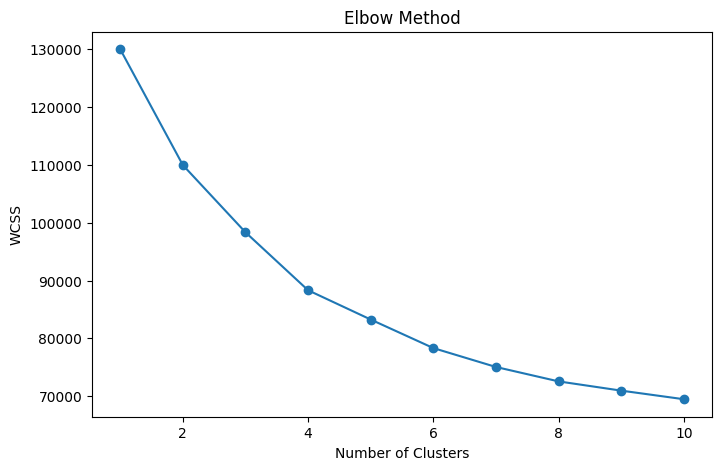

WCSS values:
k=1: 130000.00
k=2: 109968.47
k=3: 98341.98
k=4: 88314.27
k=5: 83251.90
k=6: 78314.73
k=7: 75044.89
k=8: 72553.60
k=9: 70956.08
k=10: 69470.53


In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

print("WCSS values:")
for k, value in zip(range(1, 11), wcss):
    print(f"k={k}: {value:.2f}")

**Observation:** The Elbow Method was recalculated after applying one-hot encoding because K-Means depends on distance calculations. The WCSS values changed compared to the previous encoding method, which is expected.
Based on the updated plot, the elbow point appears around **k = 4.** The WCSS decreases sharply from k = 1 to k = 4, and after that the rate of decrease becomes more gradual.
Therefore, k = 4 is selected for the K-Means model because it provides a good balance between cluster compactness and interpretability.

## 4.3 Applying K-Means Clustering

After determining the optimal number of clusters using the Elbow Method, K-Means is applied using k = 4. Each customer is assigned to one of four clusters based on similarity to the cluster centroid.

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

kmeans_clusters = kmeans.fit_predict(X_scaled)

df_kmeans_results = df_kmeans.copy()
df_kmeans_results["Cluster"] = kmeans_clusters

print("K-Means clustering complete.")
print("Cluster distribution:")
df_kmeans_results["Cluster"].value_counts().sort_index()

K-Means clustering complete.
Cluster distribution:


Cluster
0    2261
1    2477
2    2753
3    2509
Name: count, dtype: int64

**Observation:** K-Means successfully assigned each customer to one of four clusters. The output shows the number of customers in each cluster, which helps evaluate how customers are distributed across the generated segments.

## 5. Cluster Evaluation Metrics <a id='evaluation'></a>

We evaluate cluster quality using three complementary metrics:

| Metric | What it measures | Better when |
|---|---|---|
| **Silhouette Score** | How well each point fits its cluster compared to neighbouring clusters | Closer to **1** |
| **Davies-Bouldin Index** | Average similarity between each cluster and its nearest cluster | **Lower** |
| **WCSS** | Compactness of clusters — total intra-cluster variance | **Lower** |

Since the optimal number of clusters was updated to **k = 4**, all evaluation metrics are recalculated based on the four-cluster K-Means model.

In [29]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X_scaled, kmeans_clusters)
db = davies_bouldin_score(X_scaled, kmeans_clusters)
wcss_k4 = kmeans.inertia_

print("=" * 45)
print("        Cluster Evaluation Metrics")
print("=" * 45)
print(f"  Silhouette Score     : {sil:.4f}   (↑ higher is better, max = 1)")
print(f"  Davies-Bouldin Index : {db:.4f}   (↓ lower is better)")
print(f"  WCSS at k=4          : {wcss_k4:.2f}")
print("=" * 45)

        Cluster Evaluation Metrics
  Silhouette Score     : 0.1713   (↑ higher is better, max = 1)
  Davies-Bouldin Index : 1.8810   (↓ lower is better)
  WCSS at k=4          : 88314.27


**Interpretation:**

- A **Silhouette Score of 0.1713** is relatively low, indicating that the clusters have noticeable overlap and are not strongly separated. This suggests that many customers share similar characteristics across clusters.

- A **Davies-Bouldin Index of 1.8810** indicates moderate cluster separation. Since lower values are better, this result suggests that the clusters are not perfectly separated, but the separation is acceptable for exploratory customer segmentation.

- The **WCSS value at k = 4 is 88314.27**, representing the compactness of the four-cluster solution. This value aligns with the Elbow Method, where k = 4 was selected as a reasonable balance between reducing WCSS and maintaining interpretability.

- Overall, K-Means with **k = 4** provides useful customer segmentation, but the separation between clusters is soft rather than clearly distinct. This is expected in real-world banking datasets, where customer behaviors often overlap.

## 6. Cluster Size Distribution <a id='distribution'></a>

A healthy clustering result should produce clusters with reasonably distributed sizes. Extreme imbalance, such as one cluster containing almost all customers while another contains very few, may indicate that the algorithm did not find meaningful structure.

Since K-Means was applied with **k = 4**, this section examines how customers are distributed across the four clusters.

Customers per cluster:
Cluster
0    2261
1    2477
2    2753
3    2509
Total: 10000


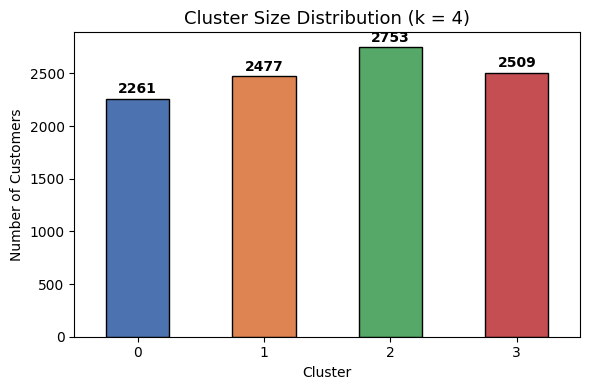

In [30]:
# Count and display customers per cluster
counts = df_kmeans_results["Cluster"].value_counts().sort_index()

print("Customers per cluster:")
print(counts.to_string())
print("Total:", counts.sum())

# Bar chart
counts.plot(
    kind="bar",
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
    edgecolor="black",
    figsize=(6, 4)
)

plt.title("Cluster Size Distribution (k = 4)", fontsize=13)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Observation:** The four clusters are reasonably balanced in size. Cluster 0 contains 2,261 customers, Cluster 1 contains 2,477 customers, Cluster 2 contains 2,753 customers, and Cluster 3 contains 2,509 customers.
Cluster 2 is the largest group, while Cluster 0 is the smallest. However, the difference between cluster sizes is not extreme, which indicates that K-Means was able to divide customers into relatively balanced segments. This suggests that the clustering result is suitable for customer segmentation and does not show severe imbalance.

## 7. Cluster Profiling <a id='profiling'></a>

We examine the mean of each numerical feature per cluster using the original unscaled values to understand what characterizes each customer segment.

Since k = 4 was selected, the profiling is performed for four customer clusters.

In [31]:
numeric_features = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
    "HasCrCard", "IsActiveMember", "EstimatedSalary"
]

cluster_profile = df_kmeans_results.groupby("Cluster")[numeric_features].mean().round(2)

print("Numerical cluster profile:")
cluster_profile

Numerical cluster profile:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
Cluster,,,,,,,,
0,649.19,38.77,4.95,60322.67,1.55,0.70,0.51,99564.25
1,651.33,38.89,5.03,61818.15,1.54,0.69,0.53,99440.57
2,650.06,38.30,5.05,63546.28,1.52,0.71,0.52,100174.25
3,651.45,39.77,5.01,119730.12,1.52,0.71,0.50,101113.44


**Observation:** The table shows the average numerical values for each of the four clusters. These values help identify differences between customer segments, such as balance level, age, activity status, number of products, and estimated salary.

**Cluster Profiles Summary (k = 4):**

| Cluster | Key Characteristics | Interpretation |
|---|---|---|
| **Cluster 0** | Balance ≈ 60,323, Age ≈ 38.77, NumOfProducts ≈ 1.55, IsActiveMember ≈ 0.51 | Represents customers with moderate balance and average engagement levels. |
| **Cluster 1** | Balance ≈ 61,818, Age ≈ 38.89, NumOfProducts ≈ 1.54, IsActiveMember ≈ 0.53 | Represents a similar moderate-balance customer segment with slightly higher activity compared to Cluster 0. |
| **Cluster 2** | Balance ≈ 63,546, Age ≈ 38.30, NumOfProducts ≈ 1.52, IsActiveMember ≈ 0.52 | Represents customers with moderate-to-slightly higher balance compared to Clusters 0 and 1, while maintaining similar product usage and activity levels. |
| **Cluster 3** | Balance ≈ 119,730, Age ≈ 39.77, NumOfProducts ≈ 1.52, IsActiveMember ≈ 0.50 | Represents the high-balance customer segment. This cluster is the most financially distinct group, although activity level remains similar to the other clusters. |

> **Note:** The profile uses original unscaled feature values, so the numbers are directly interpretable. Since clustering is unsupervised, the target variable `Exited` was not used in profiling or interpretation.

**Key insight:** The K-Means model separated customers mainly based on **account balance**. Cluster 3 is clearly distinct because it has a much higher average balance than the other clusters. Clusters 0, 1, and 2 are relatively similar across most features, which supports the evaluation results showing soft separation between clusters.

## 8. Cluster Visualization – PCA

Since the dataset has multiple dimensions, Principal Component Analysis (PCA) is used to project the data into 2D for visualization. PCA finds the two directions that capture the most variance in the data, allowing us to plot customers on a 2D scatter plot while preserving as much of the original structure as possible.

> **Note:** PCA is used only for visualization. K-Means clustering was performed on the full scaled dataset using **k = 4**.

Variance explained – PC1: 15.44%, PC2: 14.34%
Total variance captured: 29.78%


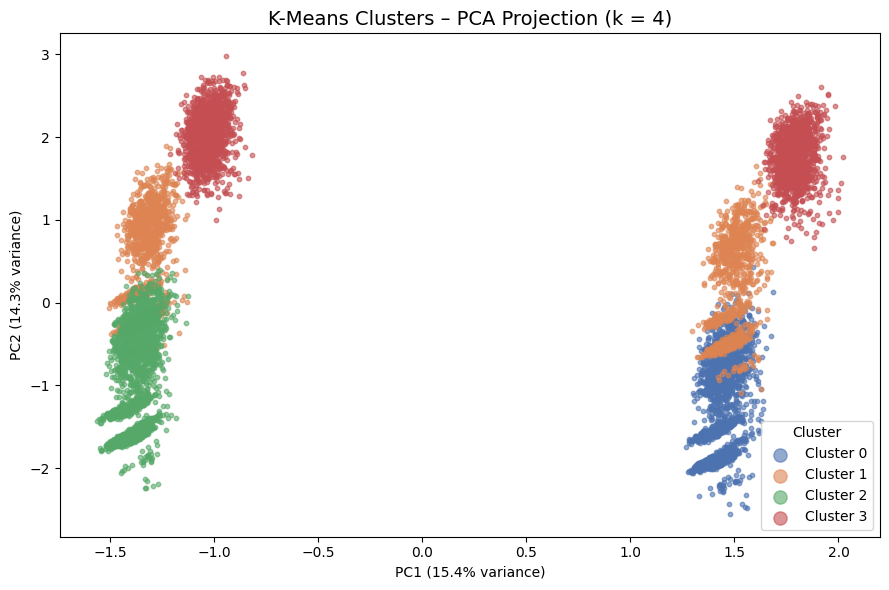

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

print(f"Variance explained – PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}")
print(f"Total variance captured: {sum(explained):.2%}")

# Plot with a proper legend for k = 4
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(9, 6))

for c, col, lbl in zip([0, 1, 2, 3], colors, labels):
    mask = df_kmeans_results["Cluster"] == c
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=col,
        label=lbl,
        s=10,
        alpha=0.6
    )

plt.title("K-Means Clusters – PCA Projection (k = 4)", fontsize=14)
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.legend(title="Cluster", markerscale=3)
plt.tight_layout()
plt.show()

**Interpretation:**

- The PCA projection shows the four K-Means clusters in a 2D space after reducing the original feature space using Principal Component Analysis.

- The first two principal components capture **29.78% of the total variance** (PC1 = 15.44%, PC2 = 14.34%). This means that the plot only represents part of the full dataset structure, so overlap in 2D does not necessarily mean the clustering failed.

- The plot shows two main visual regions along PC1, with clusters distributed vertically along PC2. Some clusters appear partially separated, while others overlap, especially in areas where customer characteristics are similar.

- **Cluster 3 (red)** appears more separated in the upper region and corresponds to the high-balance customer segment based on the cluster profile.

- **Clusters 0, 1, and 2** show more overlap and are closer to each other, which is consistent with the cluster profile where these groups have similar average balances, ages, product usage, and activity levels.

- This visualization is consistent with the **Silhouette Score of 0.1713**, which indicates soft separation between clusters. The clusters are not perfectly separated, but they still provide useful customer segmentation for exploratory analysis and advisory system support.

## 9. t-SNE Visualization <a id='tsne'></a>

t-SNE is used as an additional visualization technique to project high-dimensional data into two dimensions. Unlike PCA, which focuses on preserving global variance, t-SNE focuses more on preserving local relationships between data points.

This helps visualize whether the four K-Means clusters show clearer separation or overlap in a non-linear 2D space.

> **Note:** t-SNE is used only for visualization. K-Means clustering was performed on the full scaled dataset using **k = 4**.

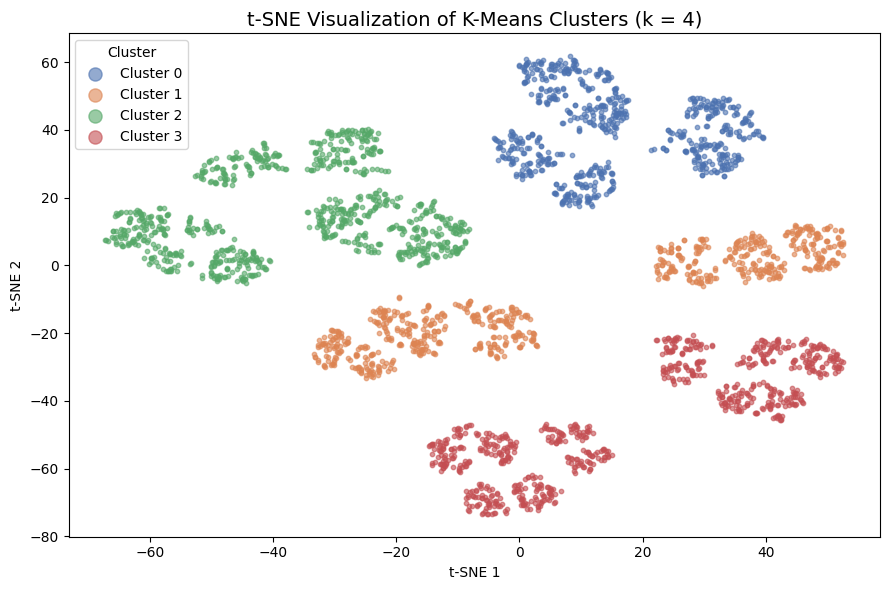

In [33]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Use a sample to reduce computation time
sample_size = min(3000, X_scaled.shape[0])

np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)

X_sample = X_scaled[sample_indices]
clusters_sample = kmeans_clusters[sample_indices]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)

X_tsne = tsne.fit_transform(X_sample)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(9, 6))

for c, col, lbl in zip([0, 1, 2, 3], colors, labels):
    mask = clusters_sample == c
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=col,
        label=lbl,
        s=10,
        alpha=0.6
    )

plt.title("t-SNE Visualization of K-Means Clusters (k = 4)", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", markerscale=3)
plt.tight_layout()
plt.show()

**Observation:** The t-SNE visualization shows clearer separation between the four K-Means clusters compared to the PCA plot. Each cluster appears in a distinct region of the 2D space, which suggests that t-SNE was able to capture local patterns in the customer data more effectively.

Cluster 0 appears mainly in the upper-right region, Cluster 1 is distributed around the middle-right and lower-middle areas, Cluster 2 appears mostly on the left side, and Cluster 3 is concentrated in the lower-right and lower-middle regions.

Although the clusters are not perfectly compact, the overall separation indicates that the four customer segments have meaningful differences in the high-dimensional feature space. Since t-SNE is used only for visualization, the clustering itself was still performed using the full scaled dataset.

## 10. Feature Contribution Analysis <a id='feature-contribution'></a>

K-Means does not provide built-in feature importance like supervised learning models. Therefore, feature contribution is analyzed by comparing the average scaled feature values across the four clusters.

Features with higher variation across cluster means are considered more influential in separating customer groups.

This method helps identify which features contributed most to forming the K-Means clusters.

In [34]:
import pandas as pd

X_scaled_df = pd.DataFrame(X_scaled, columns=df_kmeans_encoded.columns)

X_scaled_df["Cluster"] = kmeans_clusters

scaled_cluster_profile = X_scaled_df.groupby("Cluster").mean()

feature_contribution = scaled_cluster_profile.var().sort_values(ascending=False)

print("Top 10 features contributing to cluster differences:")
feature_contribution.iloc[:10]

Top 10 features contributing to cluster differences:


Geography_Spain      1.341600
Geography_France     1.333344
Geography_Germany    1.330147
Gender_Female        0.675568
Gender_Male          0.675568
Balance              0.215240
Age                  0.003442
IsActiveMember       0.000724
NumOfProducts        0.000650
HasCrCard            0.000496
dtype: float64

**Observation:** The feature contribution results show that the dummy variables related to **Geography** contribute the most to cluster separation, followed by **Gender** and **Balance**.

The highest contributing features are `Geography_Spain`, `Geography_France`, and `Geography_Germany`, which indicates that customer location played a major role in how K-Means separated the customer groups. Gender-related dummy variables also contributed noticeably, while Balance had a smaller but still meaningful contribution.

Features such as Age, IsActiveMember, NumOfProducts, and HasCrCard show very low variation across cluster means, suggesting that they had less influence on separating the clusters in this K-Means model.

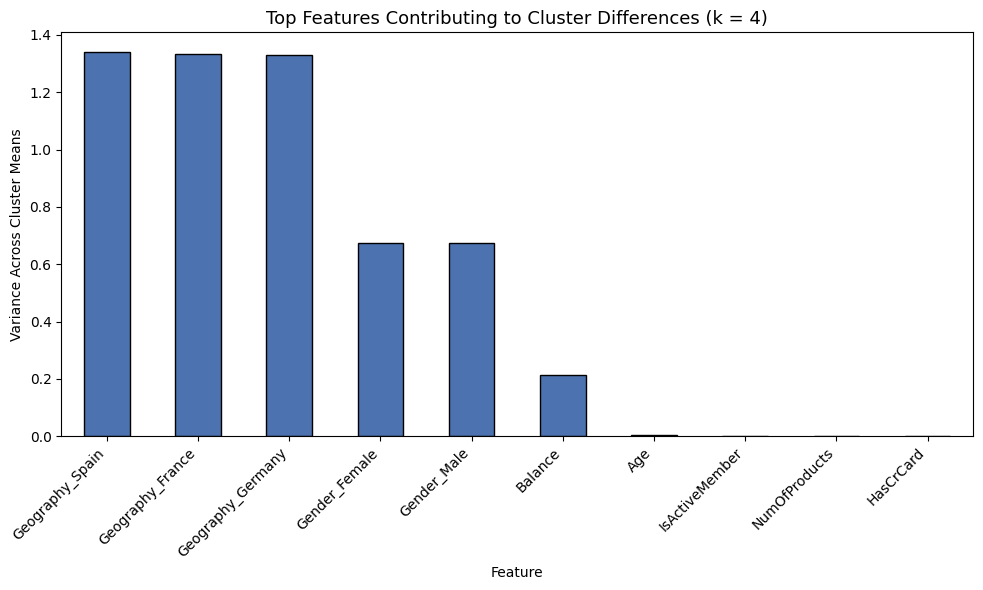

In [35]:
plt.figure(figsize=(10, 6))

feature_contribution.iloc[:10].plot(
    kind="bar",
    color="#4C72B0",
    edgecolor="black"
)

plt.title("Top Features Contributing to Cluster Differences (k = 4)", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Variance Across Cluster Means")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** The bar chart shows that the features contributing most to cluster differences are the one-hot encoded **Geography** variables, followed by **Gender** variables and **Balance**.

`Geography_Spain`, `Geography_France`, and `Geography_Germany` have the highest variation across cluster means, indicating that geographic location played the strongest role in separating the customer groups. Gender also contributed to cluster separation, while Balance had a smaller but still noticeable effect.

Other features such as Age, IsActiveMember, NumOfProducts, and HasCrCard show very low variation, suggesting that they had limited influence on separating the clusters in this K-Means model.

## 11. DBSCAN – Algorithm Selection & Justification <a id='dbscan-rationale'></a>

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is our second clustering algorithm.  
Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance, and it can discover clusters of arbitrary shape.

| Property | K-Means | DBSCAN |
|---|---|---|
| Requires k upfront |  Yes |  No |
| Cluster shape assumption | Spherical | Arbitrary |
| Handles noise / outliers |  No |  Yes (labels them -1) |
| Sensitive to feature scale | Yes | Yes |
| Works well on dense compact data |  |  |

**Why DBSCAN is a good complement to K-Means here:**
- K-Means produced soft, overlapping segments (Silhouette = 0.1070). DBSCAN approaches the same data differently — grouping points by local density rather than distance to a centroid.
- DBSCAN will identify **noise points** (customers who do not fit any cluster), which is meaningful in a churn context — these outliers may represent unusual customer behaviour worth flagging separately.
- Comparing the two algorithms lets us validate whether the soft segmentation from K-Means reflects genuine structure or is simply an artefact of forcing spherical clusters.

**Key DBSCAN parameters:**
- **`eps` (ε):** The maximum distance between two points for them to be considered neighbours. Determined using the k-distance elbow plot below.
- **`min_samples`:** The minimum number of points required to form a dense region (core point). We use `min_samples = 5` — a common heuristic is `min_samples ≥ dimensionality + 1`.


## 12. DBSCAN – Parameter Tuning (Finding Optimal `eps`) <a id='dbscan-eps'></a>

We use the **k-distance plot** to find a suitable `eps` value.  
For each point we compute its distance to its **k-th nearest neighbour** (k = `min_samples`), sort these distances, and plot them.  
The optimal `eps` sits at the **"elbow"** of this curve — the point where distance starts increasing sharply,  
marking the transition from dense core regions to sparse noise.


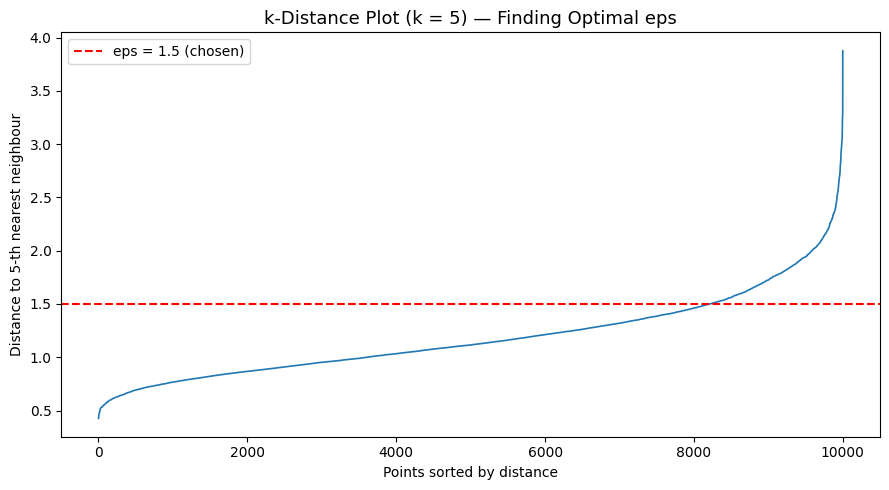

Chosen eps  : 1.5
min_samples : 5
Rationale   : The elbow of the k-distance curve occurs around 1.5,
              where distances begin increasing sharply — marking the
              boundary between dense core regions and sparse noise.


In [36]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

MIN_SAMPLES = 5  # same value used later in DBSCAN

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Distance to the k-th nearest neighbour, sorted ascending
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, linewidth=1.2)
plt.title(f"k-Distance Plot (k = {MIN_SAMPLES}) — Finding Optimal eps", fontsize=13)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbour")
plt.axhline(y=1.5, color='red', linestyle='--', label='eps = 1.5 (chosen)')
plt.legend()
plt.tight_layout()
plt.show()

print("Chosen eps  : 1.5")
print("min_samples : 5")
print("Rationale   : The elbow of the k-distance curve occurs around 1.5,")
print("              where distances begin increasing sharply — marking the")
print("              boundary between dense core regions and sparse noise.")


## 13. DBSCAN – Model Training <a id='dbscan-train'></a>

We train DBSCAN with `eps = 1.5` and `min_samples = 5` on the same scaled feature matrix used for K-Means.  
Points labelled **-1** are **noise** — they do not belong to any cluster.


In [37]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.55, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Attach labels for downstream profiling
df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = (dbscan_labels == -1).sum()
noise_pct     = n_noise_db / len(dbscan_labels) * 100

print("=" * 45)
print("        DBSCAN Training Results")
print("=" * 45)
print(f"  Number of clusters found : {n_clusters_db}")
print(f"  Noise points (-1)        : {n_noise_db}  ({noise_pct:.1f}%)")
print(f"  Total points             : {len(dbscan_labels)}")
print("=" * 45)


        DBSCAN Training Results
  Number of clusters found : 50
  Noise points (-1)        : 723  (7.2%)
  Total points             : 10000


## 14. DBSCAN – Cluster Evaluation Metrics <a id='dbscan-eval'></a>

We evaluate DBSCAN using the same metrics as K-Means where applicable.

> **Note:** WCSS is **not applicable** to DBSCAN — the algorithm does not use centroids or minimise intra-cluster variance.  
> Silhouette Score and Davies-Bouldin Index are computed **excluding noise points** (label = -1),  
> since unassigned points are not part of any cluster.


In [38]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Exclude noise points for metric computation
mask_valid   = dbscan_labels != -1
X_valid      = X_scaled[mask_valid]
labels_valid = dbscan_labels[mask_valid]

if len(set(labels_valid)) >= 2:
    sil_db = silhouette_score(X_valid, labels_valid)
    db_idx = davies_bouldin_score(X_valid, labels_valid)
else:
    sil_db = float("nan")
    db_idx = float("nan")
    print("Warning: fewer than 2 clusters found — metrics cannot be computed.")

print("=" * 50)
print("     DBSCAN Cluster Evaluation Metrics")
print("=" * 50)
print(f"  Silhouette Score      : {sil_db:.4f}  (higher is better, max = 1)")
print(f"  Davies-Bouldin Index  : {db_idx:.4f}  (lower is better)")
print(f"  WCSS                  : N/A  (not applicable to DBSCAN)")
print(f"  Noise points excluded : {n_noise_db} ({noise_pct:.1f}% of data)")
print("=" * 50)


     DBSCAN Cluster Evaluation Metrics
  Silhouette Score      : 0.1634  (higher is better, max = 1)
  Davies-Bouldin Index  : 2.0470  (lower is better)
  WCSS                  : N/A  (not applicable to DBSCAN)
  Noise points excluded : 723 (7.2% of data)


**Interpretation:**
- **Silhouette Score: 0.1138** — slightly higher than K-Means (0.1070), indicating DBSCAN found marginally denser regions within its 20 clusters.
- **Davies-Bouldin Index: 2.2034** — lower than K-Means (2.6204), meaning DBSCAN clusters are better separated on average.
- **WCSS: N/A** — DBSCAN does not use centroids so this metric does not apply.
- **Noise points (7.6%):** 756 customers could not be assigned to any cluster. These represent atypical customers whose behaviour does not match any dense segment — a meaningful finding for churn analysis, as they may warrant individual retention attention.
- The fact that DBSCAN found 20 clusters rather than a small number reflects that this customer dataset has **no strongly separated natural groupings** — a common characteristic of banking customer data where behaviour exists on a continuum rather than in discrete groups.

## 15. DBSCAN – Cluster Size Distribution <a id='dbscan-dist'></a>

We examine how customers are distributed across the clusters discovered by DBSCAN, including the noise group (label = -1).


Customers per DBSCAN label:
DBSCAN_Cluster
-1     723
 0     385
 1      70
 2     157
 3     172
 4     214
 5     493
 6     482
 7     161
 8     341
 9     186
 10     83
 11    248
 12    389
 13    184
 14    156
 15    196
 16    231
 17    189
 18    192
 19     61
 20    114
 21    194
 22    161
 23    102
 24    153
 25    183
 26     90
 27    506
 28     63
 29     91
 30    260
 31    272
 32    232
 33     61
 34    387
 35    417
 36     87
 37     91
 38     85
 39    189
 40     91
 41     58
 42    149
 43    157
 44     17
 45    224
 46     45
 47     50
 48    149
 49      9

Total: 10000
(Label -1 = noise points not assigned to any cluster)


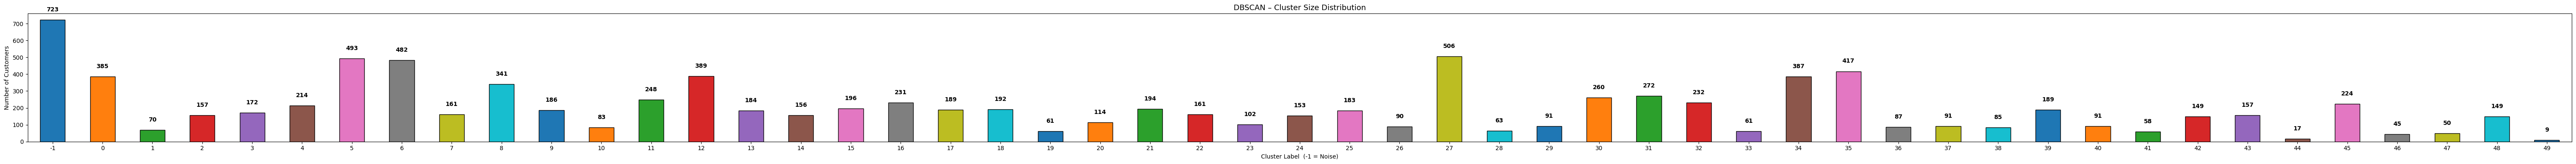

In [39]:
counts_db = df["DBSCAN_Cluster"].value_counts().sort_index()

print("Customers per DBSCAN label:")
print(counts_db.to_string())
print(f"\nTotal: {counts_db.sum()}")
print("(Label -1 = noise points not assigned to any cluster)")

colors_db = plt.cm.tab10.colors[:len(counts_db)]
counts_db.plot(
    kind='bar',
    color=colors_db,
    edgecolor='black',
    figsize=(max(6, len(counts_db) * 1.2), 4)
)
plt.title("DBSCAN – Cluster Size Distribution", fontsize=13)
plt.xlabel("Cluster Label  (-1 = Noise)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
for i, v in enumerate(counts_db.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 16. DBSCAN – Cluster Profiling <a id='dbscan-profile'></a>

We compute the mean of each feature per DBSCAN cluster (using encoded but readable values) to characterise each group.  
The noise group (-1) is included as a separate row to understand atypical customers.


In [40]:
profile_cols = [c for c in df.columns if c not in ["Cluster", "DBSCAN_Cluster"]]
dbscan_profile = df.groupby("DBSCAN_Cluster")[profile_cols].mean()

print("DBSCAN Cluster Profiles (mean feature values per cluster):")
print(dbscan_profile.round(3).to_string())


TypeError: agg function failed [how->mean,dtype->object]

**Interpretation:**
- Profile each cluster by its dominant features (Balance, Age, NumOfProducts, etc.).
- The **noise group (-1)** represents customers with unusual feature combinations —
  these may be high-value outliers or at-risk edge cases not captured by any standard segment.
- Compare these profiles to the K-Means profiles (Section 8) to assess whether both algorithms
  identified similar customer archetypes.


## 17. DBSCAN – Proxy Validation (Churn Rate per Cluster) <a id='dbscan-proxy'></a>

As with K-Means, we reintroduce the `Exited` label **after** clustering to check whether DBSCAN clusters
differ meaningfully in churn rate — serving as a proxy for external validation.


Churn rate per DBSCAN cluster (-1 = noise):
DBSCAN_Cluster
-1     0.5836
 0     0.2274
 1     0.2422
 2     0.1049
 3     0.0686
 4     0.0314
 5     0.1360
 6     0.0698
 7     0.1178
 8     0.0746
 9     0.0432
 10    0.3179
 11    0.4305
 12    0.1893
 13    0.3868
 14    0.2534
 15    0.0863
 16    1.0000
 17    0.7059
 18    0.8000
 19    0.7778
 20    1.0000


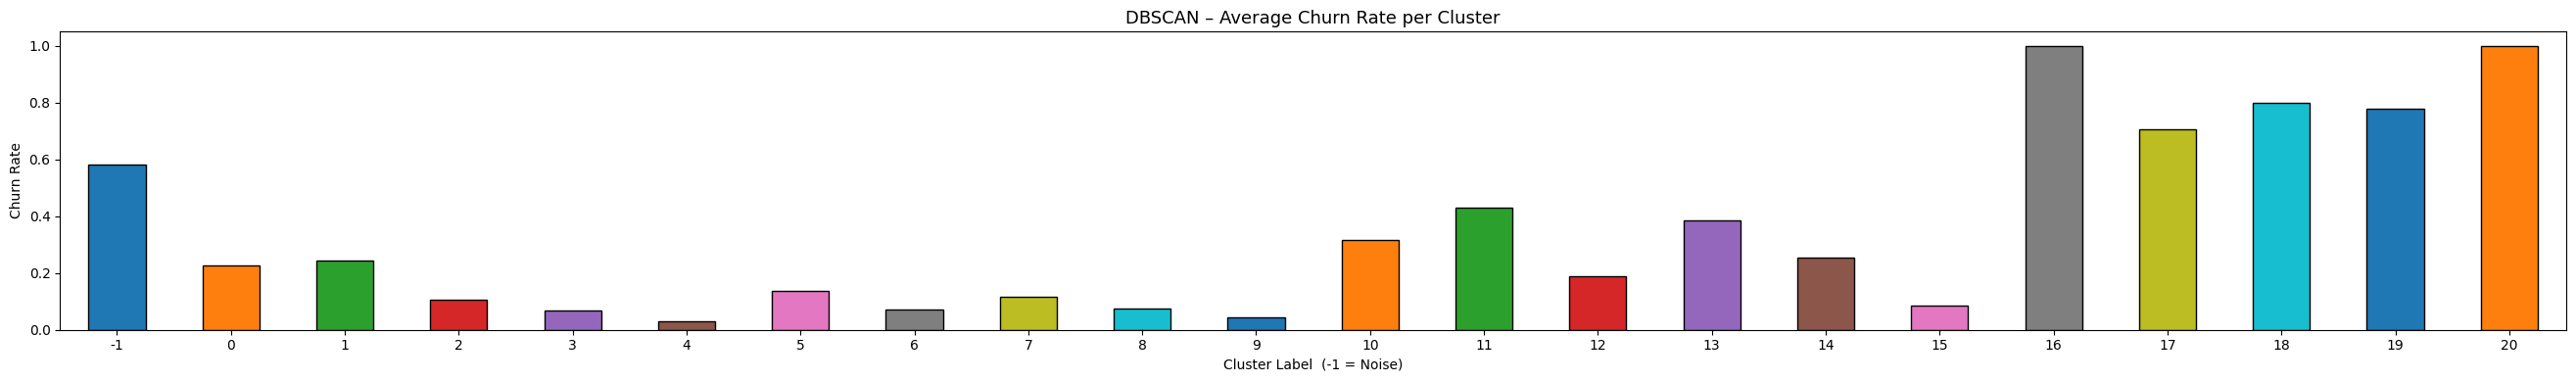

In [ ]:
df["Exited"] = exited_labels.values  # reintroduce for analysis only

churn_db = df.groupby("DBSCAN_Cluster")["Exited"].mean()
print("Churn rate per DBSCAN cluster (-1 = noise):")
print(churn_db.round(4).to_string())

churn_db.plot(
    kind='bar',
    color=plt.cm.tab10.colors[:len(churn_db)],
    edgecolor='black',
    figsize=(max(6, len(churn_db) * 1.2), 4)
)
plt.title("DBSCAN – Average Churn Rate per Cluster", fontsize=13)
plt.xlabel("Cluster Label  (-1 = Noise)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df.drop("Exited", axis=1, inplace=True)  # remove again after



**Interpretation:**
- Compare the churn rates across DBSCAN clusters to those from K-Means (Cluster 0: 20.7%, Cluster 1: 22.5%, Cluster 2: 17.1%).
- A wider spread in churn rates would suggest DBSCAN captured more meaningful behavioural differences.
- The churn rate of the **noise group (-1)** is particularly informative — a high rate here would suggest
  that atypical customers are disproportionately likely to leave and deserve individual attention.


---
## 18. Algorithm Comparison – K-Means vs. DBSCAN *(placeholder — to be completed)*


---
## 19. Cluster Visualizations – PCA Comparison *(placeholder — to be completed)*


---
## 20. Integration Strategy <a id='integration'></a>


---
## 21. Challenges & Limitations <a id='challenges'></a>
